In [1]:
#!pip install pypsa

In [ ]:
# Needed imports 
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Path extention
sys.path.append('../src')
sys.path.append('../data')

# Functions import
from Load_Data import load_parquet, construct_dataframe, read_csv
from Plot_Functions import plot_timeseries, compute_market_price_by_country, create_simple_network
from cost_dict import cost_dict  # as to be a cost_dict.py files

### Loading data

In [ ]:
df = read_csv("../data/France-2023.csv")
df.head()


,DateTime,Prod_Nuclear_FR,Prod_Wind_FR,Prod_Solar_FR,Prod_Hydro_FR,Prod_Gas_FR,Prod_Oil_FR,Demand_FR,link_FR_ES,Price_FR
0,2023-01-01 01:00:00,40200.07860418361,6334.820759927363,397.0615627926673,3433.1911629643146,2424.685468751506,510.68543635736506,49191.8631077668,-919.5359158508885,77.43571469510985
1,2023-01-01 02:00:00,40489.36899205287,5263.595724808784,787.1368519259374,3487.7607525014428,2374.1699803342253,645.1188728421157,52259.96541543158,-1095.3267467906996,70.05441522290648
2,2023-01-01 03:00:00,41120.44659960073,6432.654408237131,1163.3625167937064,3427.9016711963054,2463.5754243648107,502.2854917250062,55848.2094050262,-1197.4247570167252,78.44695963593266
3,2023-01-01 04:00:00,40933.77899507499,5578.812185894402,1519.1188900729314,3005.857042092501,2277.6287062947317,654.1161497005553,54561.97778976417,-1133.8667684469833,70.82761587514271
4,2023-01-01 05:00:00,39511.3610600618,5366.382724014234,1848.1464603610927,3179.989032239182,2586.784346458169,529.389329080075,56018.57303512443,-1564.0056657350033,78.46612135778327


### Visualisation of some dataset variables: 

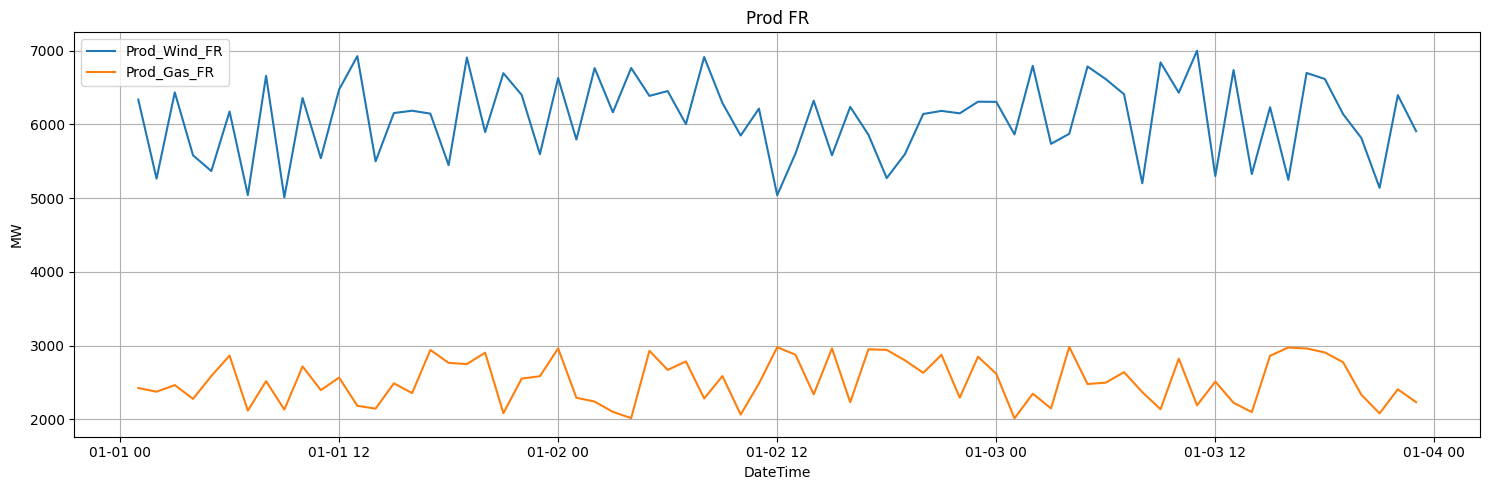

In [ ]:
plot_timeseries(df, variables=['Prod_Wind_FR', 'Prod_Gas_FR'], title='Prod FR', ylabel='MW')


### Implementation of a standardized de-normalization function, allowing different functions and estimations to be applied on normalized data

In [5]:
df_fr = construct_dataframe(df, countries=['FR'], production_name=['Wind', 'Gas', 'Solar', 'Coal', 'Oil', 'Nuclear'])
df_fr.head()

,DateTime,Prod_Wind_FR,Prod_Gas_FR,Prod_Solar_FR,Prod_Oil_FR,Prod_Nuclear_FR,link_FR_ES,Demand_FR,Price_FR
0,2023-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,6334.820759927363,2424.685468751506,397.0615627926673,510.68543635736506,40200.07860418361,-919.5359158508885,49191.8631077668,77.43571469510985
2,2023-01-01 02:00:00,5263.595724808784,2374.1699803342253,787.1368519259374,645.1188728421157,40489.36899205287,-1095.3267467906996,52259.96541543158,70.05441522290648
3,2023-01-01 03:00:00,6432.654408237131,2463.5754243648107,1163.3625167937064,502.2854917250062,41120.44659960073,-1197.4247570167252,55848.2094050262,78.44695963593266
4,2023-01-01 04:00:00,5578.812185894402,2277.6287062947317,1519.1188900729314,654.1161497005553,40933.77899507499,-1133.8667684469833,54561.97778976417,70.82761587514271


### Creation of a cost function, estimating electricity price using the SPOT market, returning the dataframe with the estimated price and the source of the last technology called

In [6]:
# Vérifie si 'DateTime' est dans l'index
if df.index.name == 'DateTime':
    df = df.reset_index()

# Si 'DateTime' n’est ni dans les colonnes ni dans l’index : erreur
if 'DateTime' not in df.columns:
    raise ValueError("Le DataFrame doit contenir une colonne 'DateTime'.")

# Ajoute la colonne country si besoin
df['country'] = 'FR'

# Appel de la fonction
spot_price_df = compute_market_price_by_country(df, cost_dict)
spot_price_df[['Estimated_Price_FR','marginal_tech_FR']].head()


,Estimated_Price_FR,marginal_tech_FR
0,60,Hydro
1,135,Gas
2,220,Oil
3,220,Oil
4,220,Oil


### Visualization of the difference between real and estimed price

Since this price model is calculated on an hourly basis, the results are not satisfactory. By only considering production, the model does not follow the actual price evolution. Storage and interconnections should also be included, but these values are missing.

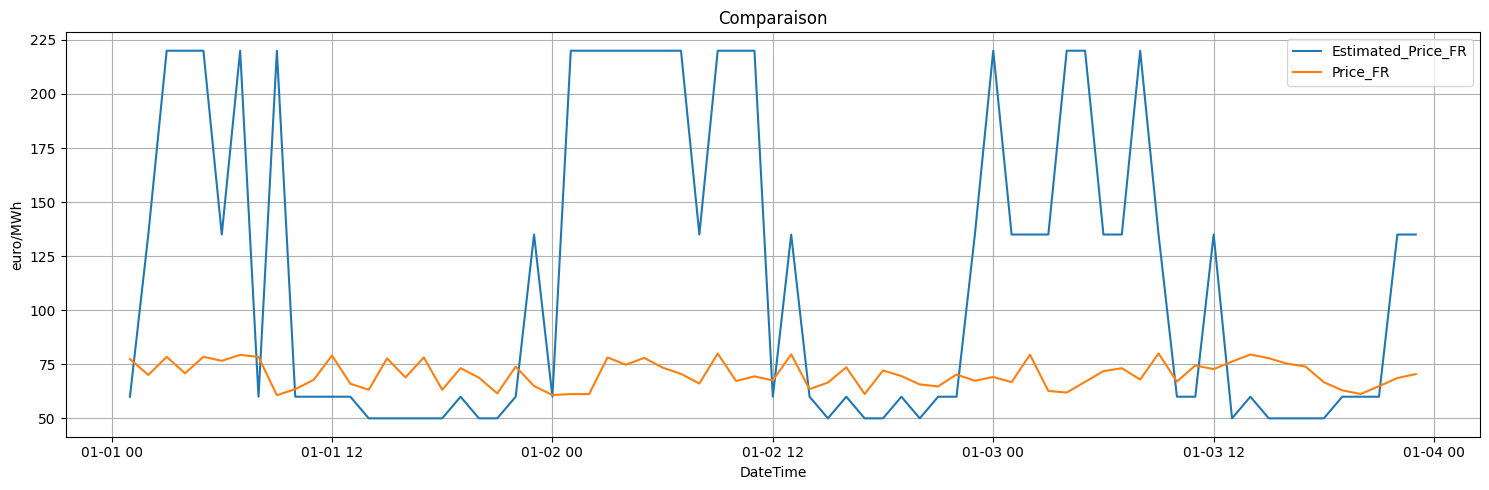

In [7]:
plot_timeseries(df, variables=['Estimated_Price_FR', 'Price_FR'], title='Comparaison', ylabel='euro/MWh')


Avertissement : colonne Demand_ES manquante.
Avertissement : colonne Demand_DE manquante.


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2b04601b460>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x2b04605c0a0>},
 'flows': {}}

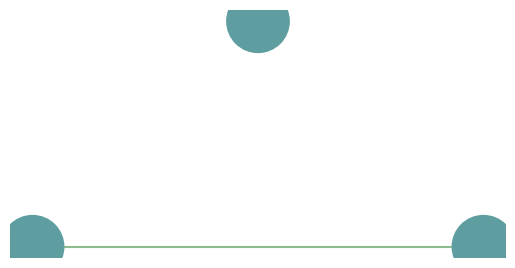

In [8]:
# Liste de pays présent dans le réseau
countries = ['FR','ES','DE']

# Création du réseau
net = create_simple_network(df,countries, cost_dict)

# Affichage du réseau
net.plot.map()